**Practical No.6**

Aim:To design and implement an artificial Neural Network for classification problems and evaluate its learning performance.

Name:Vedanti Ramde  Roll No:CS23513

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
path= "/content/drive/MyDrive/ml_dataset/Heart_Failure_Prediction_dataset.csv"
df=pd.read_csv(path)
df.head(5)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [ ]:
df.shape

(918, 12)

In [ ]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [ ]:
df.isnull().any().any()

np.False_

In [ ]:
df.isnull().sum

<bound method DataFrame.sum of        Age    Sex  ChestPainType  RestingBP  Cholesterol  FastingBS  \
0    False  False          False      False        False      False   
1    False  False          False      False        False      False   
2    False  False          False      False        False      False   
3    False  False          False      False        False      False   
4    False  False          False      False        False      False   
..     ...    ...            ...        ...          ...        ...   
913  False  False          False      False        False      False   
914  False  False          False      False        False      False   
915  False  False          False      False        False      False   
916  False  False          False      False        False      False   
917  False  False          False      False        False      False   

     RestingECG  MaxHR  ExerciseAngina  Oldpeak  ST_Slope  HeartDisease  
0         False  False           False    False     False         False  
1         False  False           False    False     False         False  
2         False  False           False    False     False         False  
3         False  False           False    False     False         False  
4         False  False           False    False     False         False  
..          ...    ...             ...      ...       ...           ...  
913       False  False           False    False     False         False  
914       False  False           False    False     False         False  
915       False  False           False    False     False         False  
916       False  False           False    False     False         False  
917       False  False           False    False     False         False  

[918 rows x 12 columns]>

In [ ]:
df[df.isnull().any(axis=1)]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease


In [ ]:
# Remove spaces (good practice)
df.columns = df.columns.str.strip()

# Define features (X) and target (y)
X = df.drop(columns=['HeartDisease'])
y = df['HeartDisease']

# Check shapes
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (918, 11)
y shape: (918,)


In [ ]:
y

,HeartDisease
0,0
1,1
2,0
3,1
4,0
...,...
913,1
914,1
915,1
916,1


In [ ]:
X

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up
...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat


In [ ]:
X=X.iloc[:,3:]

In [ ]:
X.head()

,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
0,140,289,0,Normal,172,N,0.0,Up
1,160,180,0,Normal,156,N,1.0,Flat
2,130,283,0,ST,98,N,0.0,Up
3,138,214,0,Normal,108,Y,1.5,Flat
4,150,195,0,Normal,122,N,0.0,Up


In [ ]:
X=pd.get_dummies(X,dtype=int)

In [ ]:
X.head()

,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,140,289,0,172,0.0,0,1,0,1,0,0,0,1
1,160,180,0,156,1.0,0,1,0,1,0,0,1,0
2,130,283,0,98,0.0,0,0,1,1,0,0,0,1
3,138,214,0,108,1.5,0,1,0,0,1,0,1,0
4,150,195,0,122,0.0,0,1,0,1,0,0,0,1


In [ ]:
X.shape

(918, 13)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7,test_size=0.3,random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((642, 13), (276, 13), (642,), (276,))

In [ ]:
#performing feature scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [ ]:
X_train

array([[-1.77231378,  0.2949892 , -0.52568236, ..., -0.25431598,
        -1.02524056,  1.15890711],
       [-1.23486848, -1.90539005,  1.90228942, ...,  3.93211628,
        -1.02524056, -0.86288193],
       [ 1.45235803, -1.90539005,  1.90228942, ..., -0.25431598,
         0.97538084, -0.86288193],
       ...,
       [-0.15997788,  0.47365248, -0.52568236, ..., -0.25431598,
        -1.02524056,  1.15890711],
       [ 1.02240179, -1.90539005, -0.52568236, ..., -0.25431598,
        -1.02524056,  1.15890711],
       [ 0.91491273,  1.78071537, -0.52568236, ..., -0.25431598,
         0.97538084, -0.86288193]])

In [ ]:
X_test

array([[ 0.37746742, -0.07174067, -0.52568236, ..., -0.25431598,
        -1.02524056,  1.15890711],
       [ 0.64619008,  2.96553496, -0.52568236, ..., -0.25431598,
         0.97538084, -0.86288193],
       [ 1.45235803, -1.90539005,  1.90228942, ..., -0.25431598,
         0.97538084, -0.86288193],
       ...,
       [-0.15997788,  0.75575238,  1.90228942, ...,  3.93211628,
        -1.02524056, -0.86288193],
       [ 1.45235803, -1.90539005, -0.52568236, ..., -0.25431598,
         0.97538084, -0.86288193],
       [-0.69742318,  1.2917422 , -0.52568236, ..., -0.25431598,
        -1.02524056,  1.15890711]])

In [ ]:
#importing necessary librarries
import numpy as np
import tensorflow as tf

In [ ]:
#initialising ANN
ann = tf.keras.models.Sequential()

In [ ]:
#creating hidden layer
#adding first hidden layer
ann.add(tf.keras.layers.Dense(units=6, activation='relu'))

#units:-no. of neurons that will be present in the respective layer
#Activation:- specify which activation function to be used

In [ ]:
#adding second hidden layer
ann.add(tf.keras.layers.Dense(units=6, activation='relu'))

In [ ]:
#adding output layer
ann.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))
#sigmoid because it will give answer in 0 or 1 and as in out output Y Exited only two values i.e. 0 or 1 so we took only one neuron in output layer

In [ ]:
#compiling the ann
ann.compile(optimizer="adam",loss="binary_crossentropy",metrics=['accuracy'])

In [ ]:
#fitting the ANN to training set
ann.fit(X_train,y_train,batch_size=32,epochs=100)
#batch size means it will process the data in 32 32 32 ....batches
#epochs tells the nbo. of iteration , in iteration=1 it will be forward pass so if we get loss then using loss it will update the weights and do iteraton 2 or next iteration

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.3119 - loss: 0.8161
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4381 - loss: 0.7724
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5355 - loss: 0.7294
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5947 - loss: 0.7003
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6439 - loss: 0.6615
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6699 - loss: 0.6395
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7349 - loss: 0.6123
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6873 - loss: 0.6155
Epoch 9/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7410 - loss: 0.5801
Epoch 10/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7780 - loss: 0.5480
Epoch 11/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7933 - loss: 0.5341
Epoch 12/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accurac

In [ ]:
y_pred = ann.predict(X_test)
y_pred = (y_pred > 0.5)
y_pred

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


array([[False],
       [ True],
       [ True],
       [ True],
       [False],
       [ True],
       [ True],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [ True],
       [False],
       [ True],
       [False],
       [ True],
       [ True],
       [ True],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [ True],
       [ True],
       [False],
       [ True],
       [False],
       [ True],
       [ True],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [ True],
       [False],
       [False],
       [

In [ ]:
#Accuracy Score Classification report and confusion matrix
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
accuracy_score(y_test, y_pred)

0.8586956521739131

In [ ]:
print('Confusion Matrix:')
cm=confusion_matrix(y_test,y_pred)

print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[ 94  18]
 [ 21 143]]


In [ ]:
print(cm)

[[ 94  18]
 [ 21 143]]


In [ ]:
print('classification report')
print(classification_report(y_test, y_pred))

classification report
              precision    recall  f1-score   support

           0       0.82      0.84      0.83       112
           1       0.89      0.87      0.88       164

    accuracy                           0.86       276
   macro avg       0.85      0.86      0.85       276
weighted avg       0.86      0.86      0.86       276



<Axes: >

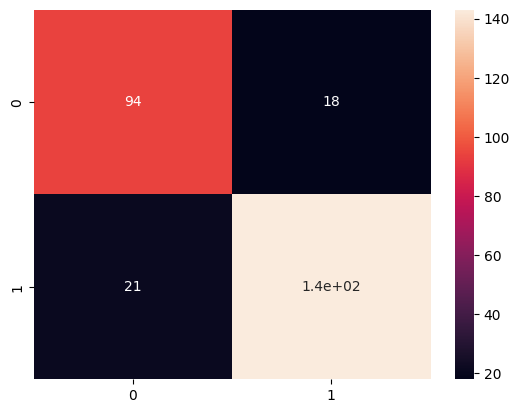

In [ ]:
import seaborn as sns
sns.heatmap(cm,annot=True)